# _4.1.5. (binary) classification using XGBoost (XGB)_

This is the main topics of the current notebook. We will focus on applying XGB to the problem of anomaly detection, i.e., detecting normal/abnormal samples whatever the anomaly degree of the case is.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
%matplotlib inline

In [2]:
import seaborn as sns 
import plotly.express as px
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors

In [3]:
import torch
import os

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [4]:
from xgboost import XGBClassifier
import time
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [5]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [6]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag2"

In [7]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

_**(normal vs abnormal)**_

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into _normal_ and _abnormal_

In [8]:
train[target].value_counts(normalize=True)

True     0.746951
False    0.253049
Name: tag2, dtype: float64

#### _c. Split_

In [9]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [10]:
torch.cuda.is_available()

True

In [11]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

### _e.  Extreme Gradient Boosting (XGB)_

- _**XGB**_ is an advanced and highly efficient implementation of _**gradient boosting**_. It includes several enhancements such as regularization, parallel processing, and a tree-pruning algorithm to prevent overfitting which make it a popular choice in numerous ML competitions.

<br>

<div style="float: center;"><img  src="https://miro.medium.com/v2/resize:fit:720/format:webp/0*g3xZsAFWEo4FpMG3.png"  alt="binary classification"  width="300"/>
</div>

</br>


We use _**DMLC/XGBoost**_, one of the most popular ML library for gradient boosting. It has grown from a research project incubated in academia to _the most widely used gradient boosting framework in production_ environment [[about]](https://opencollective.com/xgboost) [[package]](https://pypi.org/project/xgboost/)

> pip install xgboost
>
> from xgboost import XGBClassifier

In [12]:
n_estimators = 1000 if not os.getenv("CI", False) else 20

clf_xgb_chatgpt = XGBClassifier(
    max_depth=16,
    learning_rate=0.01,
    n_estimators=n_estimators,
    # objective="multi:softmax",  # Change to "multi:softmax" for discrete output
    objective='binary:logistic',
    booster='gbtree',
    n_jobs=-1,
    subsample=0.7,
    colsample_bytree=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    random_state=0,
    tree_method="gpu_hist"
)

start_time = time.time()
clf_xgb_chatgpt.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            early_stopping_rounds=40,
            verbose=100)

print(f"Training completed in {(time.time()-start_time):.2f} seconds.")

C:\Users\kabou\.conda\envs\py37\lib\site-packages\xgboost\sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


[0]	validation_0-logloss:0.68457	validation_1-logloss:0.68489
[100]	validation_0-logloss:0.25196	validation_1-logloss:0.27275
[200]	validation_0-logloss:0.12221	validation_1-logloss:0.15378
[300]	validation_0-logloss:0.07260	validation_1-logloss:0.11023
[400]	validation_0-logloss:0.05004	validation_1-logloss:0.09173
[500]	validation_0-logloss:0.03841	validation_1-logloss:0.08283
[600]	validation_0-logloss:0.03141	validation_1-logloss:0.07810
[700]	validation_0-logloss:0.02674	validation_1-logloss:0.07538
[800]	validation_0-logloss:0.02315	validation_1-logloss:0.07353
[900]	validation_0-logloss:0.02040	validation_1-logloss:0.07227
[999]	validation_0-logloss:0.01825	validation_1-logloss:0.07150
Training completed in 78.88 seconds.


In [13]:
# Get the evaluation results
clf_xgb_chatgpt.evals_result().keys()

dict_keys(['validation_0', 'validation_1'])

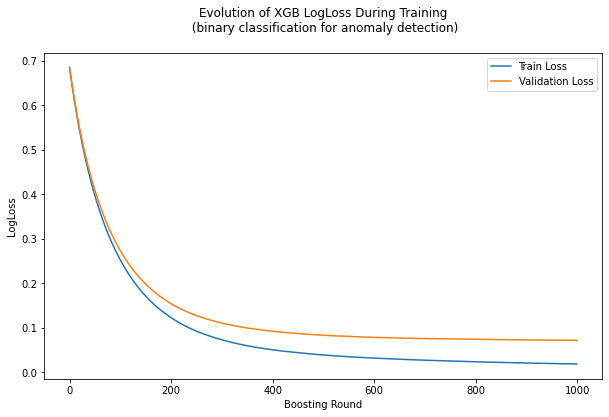

In [14]:
# Get the evaluation results
eval_results = clf_xgb_chatgpt.evals_result()

# Plot the evolution of accuracy
# train_accuracy = eval_results['train']['merror']
logloss_train = eval_results['validation_0']['logloss']
logloss_validation = eval_results['validation_1']['logloss']

plt.figure(figsize=(10, 6))
# plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(logloss_train, label='Train Loss')
plt.plot(logloss_validation, label='Validation Loss')
plt.xlabel('Boosting Round')
plt.ylabel('LogLoss')
plt.title('Evolution of XGB LogLoss During Training\n (binary classification for anomaly detection)\n')
plt.legend()
plt.show()

In [15]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = clf_xgb_chatgpt.predict(X_valid)
y_pred_train = clf_xgb_chatgpt.predict(X_train)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("\n Validation Accuracy:", round(valid_accuracy, 4))
print("\n Train Accuracy:", round(train_accuracy, 4))


 Validation Accuracy: 0.9731

 Train Accuracy: 0.9989


In [16]:
scorez = clf_xgb_chatgpt.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.217610,5,1
1,nb_nodes,0.144067,19,2
2,Del_Time,0.139368,2,3
3,P.1203,0.080188,13,4
4,Buff_Level,0.051251,8,5
5,RTT,0.044204,12,6
6,Yin,0.037138,16,7
7,Duanmu,0.037041,15,8
8,algo,0.032451,18,9
9,Arr_time,0.031444,1,10


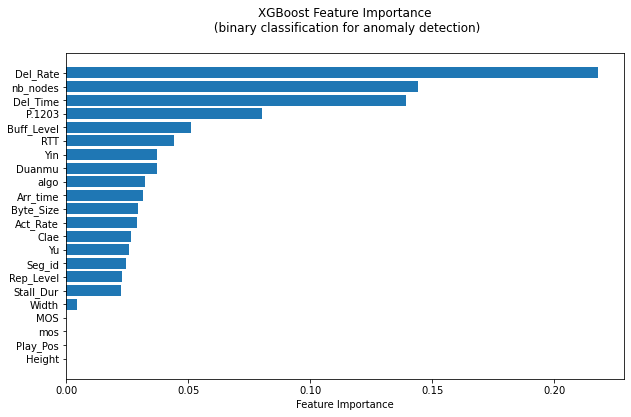

In [17]:
feature_importance = clf_xgb_chatgpt.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])


# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance\n (binary classification for anomaly detection)\n")
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf_xgb_chatgpt.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display the confusion matrix
# print("Confusion Matrix:")
# print(conf_matrix)

# Display a classification report
print("\n(XGB) Classification Report:\n(binary classification for anomaly detection)\n")
print(classification_report(y_valid, y_pred))


(XGB) Classification Report:
(binary classification for anomaly detection)

              precision    recall  f1-score   support

       False       0.94      0.96      0.95      5831
        True       0.99      0.98      0.98     16995

    accuracy                           0.97     22826
   macro avg       0.96      0.97      0.96     22826
weighted avg       0.97      0.97      0.97     22826



In [19]:
# 'normal0': 0,
# 'duplicate5': 1, 'duplicate10': 2, 'duplicate20': 3, 
# 'duplicate30': 4, 'duplicate40': 5, 'duplicate50': 6,        
# 'corrupt5': 7,   'corrupt10': 8,   'corrupt20': 9, 
# 'corrupt30': 10,  'corrupt40': 11,  'corrupt50': 12, 
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'abnormal']
[False  True]


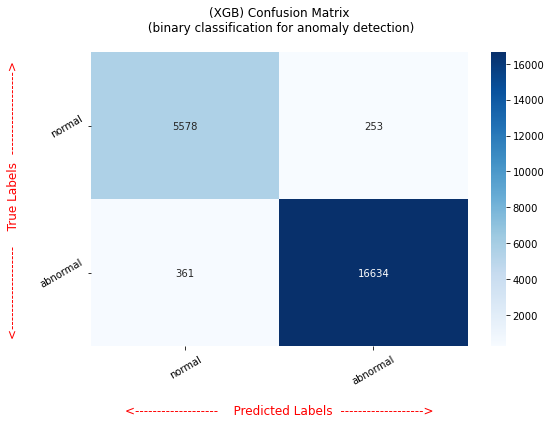

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

classes = [classe+0.5 for classe in classes]



# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(XGB) Confusion Matrix\n (binary classification for anomaly detection)\n")
plt.tight_layout()
plt.show()

#### _Hyperparameter Tunning_

Often the general effects of hyperparameters on a model are known, but how to best set a hyperparameter and combinations of interacting hyperparameters for a given dataset is challenging [[ref]](https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/).

Bellow are some suggested values for XGB hyperparameters.

In [21]:
# Suggested values for hyperparameters
learning_rate_values =     [0.01, 0.1, 0.2, 0.3]
max_depth_values =         [3, 5, 7]                  
subsample_values =         [0.5, 0.7, 0.8]            
colsample_bytree_values =  [0.5, 0.7, 0.8]     
colsample_bylevel_values = [0.5, 0.7, 0.8]   
gamma_values =             [0, 0.1, 0.2, 0.5]
min_child_weight_values =  [1, 3, 5]          
reg_alpha_values =         [0.1, 0.5, 1.0]            
reg_lambda_values =        [0.1, 0.5, 1.0]           
n_estimators_values =      [50, 100, 150]          

# Objective for multi-class classification
objectivez_value = ['binary:logistic', 'multi:softmax', 'multi:softprob']  # for discrete or probability output

In [22]:
print (X_train.shape)
print (y_train.shape)

(45650, 22)
(45650,)


### _Random Search_

Let us start with random search for an exploration of the hyperparameter space. 

In [23]:
start_time = time.time()

# Create an XGBoost classifier
clf_xgb = XGBClassifier(tree_method="gpu_hist", objective='binary:logistic')

# Define the hyperparameter search space
param_dist = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'colsample_bylevel': uniform(0.5, 0.5),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
    'n_estimators': randint(50, 300)
}

# Perform random search
random_search = RandomizedSearchCV(
    clf_xgb, param_distributions=param_dist, n_iter=40,
    scoring='accuracy', cv=4, verbose=1, pre_dispatch = 10
)

In [24]:
# Fit the model
random_search.fit(X_train, y_train)

print(f"\nTraining completed in {(time.time()-start_time):.2f} seconds.")

# Print the best hyperparameters
print("\nBest Hyperparameters:", random_search.best_params_)

Fitting 4 folds for each of 40 candidates, totalling 160 fits

Training completed in 281.59 seconds.

Best Hyperparameters: {'colsample_bylevel': 0.8239182817289141, 'colsample_bytree': 0.7993315351351179, 'gamma': 0.31864250887180856, 'learning_rate': 0.14990567947980174, 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 258, 'reg_alpha': 0.3461219315199656, 'reg_lambda': 0.6769233174434798, 'subsample': 0.6454461059896712}


In [25]:
# Get the best model
best_model = random_search.best_estimator_

# Training set
training_performance = best_model.score(X_train, y_train)
print("\n Train Accuracy with Best Model:", round (training_performance, 4))

# Evaluate the best model on your validation set
best_model_performance = best_model.score(X_valid, y_valid)
print("\n Validation Accuracy with Best Model:", round (best_model_performance, 4))


 Train Accuracy with Best Model: 0.9956

 Validation Accuracy with Best Model: 0.9725


In [26]:
scorez = best_model.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(10)

,feature,score,f_indice,rank
0,P.1203,0.140720,13,1
1,Del_Rate,0.135846,5,2
2,nb_nodes,0.105226,19,3
3,Del_Time,0.067278,2,4
4,Byte_Size,0.053670,7,5
5,Buff_Level,0.048717,8,6
6,Height,0.048442,10,7
7,Act_Rate,0.042941,6,8
8,Rep_Level,0.037801,4,9
9,Width,0.035978,9,10


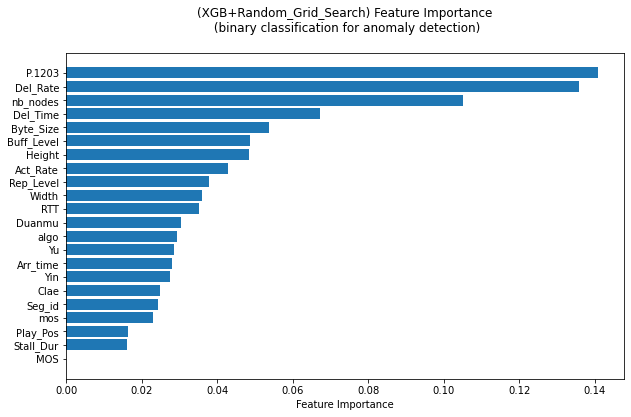

In [29]:
feature_importance = best_model.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Print and plot feature importance
# print("Feature Importance:")
# for feature, importance in sorted_features:
    # print(f"{feature}: {importance}")

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("(XGB+Random_Grid_Search) Feature Importance\n (binary classification for anomaly detection)\n")
plt.show()

In [30]:
y_pred = best_model.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display the confusion matrix
# print("Confusion Matrix:")
# print(conf_matrix)

# Display a classification report
print("\n(XGB+Random_Grid_Search) Classification Report\n (binary classification for anomaly detection)\n")
print(classification_report(y_valid, y_pred))


(XGB+Random_Grid_Search) Classification Report
 (binary classification for anomaly detection)

              precision    recall  f1-score   support

       False       0.94      0.96      0.95      5831
        True       0.99      0.98      0.98     16995

    accuracy                           0.97     22826
   macro avg       0.96      0.97      0.96     22826
weighted avg       0.97      0.97      0.97     22826



In [31]:
# 'normal0': 0,
# 'duplicate5': 1, 'duplicate10': 2, 'duplicate20': 3, 
# 'duplicate30': 4, 'duplicate40': 5, 'duplicate50': 6,        
# 'corrupt5': 7,   'corrupt10': 8,   'corrupt20': 9, 
# 'corrupt30': 10,  'corrupt40': 11,  'corrupt50': 12, 
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'abnormal']
[False  True]


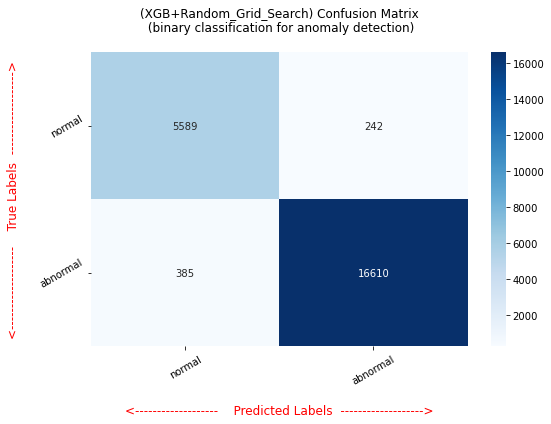

In [32]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(XGB+Random_Grid_Search) Confusion Matrix\n (binary classification for anomaly detection)\n")
plt.tight_layout()
plt.show()

### _Bayes Search CV_

For a more _robust_ approach of _hyper-parameter optimization_, let us try _**Bayesian optimization**_. 

Bayesian Optimization finds the minimum to an objective function in large problem-spaces and is very applicable to continuous values. To do this it uses Gaussian Process regression on the objective function under the hood. In our case the objective function is to arrive at the best model output given the model-parameters that we specify [[ref]](https://towardsdatascience.com/optimizing-hyperparameters-the-right-way-3c9cafc279cc).

<br>

<div style="float: center;"><img  src="https://miro.medium.com/v2/resize:fit:1400/1*sPTZiXuWHBct_kYiD_5aYA.jpeg"  alt="Bayes Search CV"  width="400"/>
</div>

</br>



Our tool of choice is _**BayesSearchCV**_. This approach uses stepwise Bayesian Optimization to explore the most promising hyperparameters in the problem-space [[package]](https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html).

In [33]:
from skopt import BayesSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
start_time = time.time()

param_space = {
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'max_depth': (3, 7),
    'subsample': (0.5, 0.8),
    'colsample_bytree': (0.5, 0.8),
    'colsample_bylevel': (0.5, 0.8),
    'gamma': (0, 0.5),
    'min_child_weight': (1, 5),
    'reg_alpha': (0.1, 1.0),
    'reg_lambda': (0.1, 1.0),
    'n_estimators': (50, 150),
}

xgb = XGBClassifier(tree_method='gpu_hist', random_state=0)

bayes_search = BayesSearchCV(
    xgb,
    param_space,
    n_iter=50,  # Adjust the number of iterations based on your computational resources
    cv=3,  # Number of cross-validation folds
    pre_dispatch = 20,  # Use all available CPU cores
    scoring='accuracy',  # Choose an appropriate metric for your problem
    random_state=0,
)

# Perform the Bayesian optimization
bayes_search.fit(X_train, y_train)

print(f"Training completed in {(time.time()-start_time):.2f} seconds.")

# Get the best hyperparameters
bayes_best_params = bayes_search.best_params_
print("Best Hyperparameters:", bayes_best_params)

Training completed in 301.85 seconds.
Best Hyperparameters: OrderedDict([('colsample_bylevel', 0.8), ('colsample_bytree', 0.8), ('gamma', 0.19784119593721297), ('learning_rate', 0.2076229405475581), ('max_depth', 7), ('min_child_weight', 1), ('n_estimators', 150), ('reg_alpha', 0.1), ('reg_lambda', 1.0), ('subsample', 0.8)])


In [39]:
# Evaluate the model on the validation set
validation_accuracy = bayes_search.score(X_valid, y_valid)
print("Validation Accuracy:", validation_accuracy)

# Evaluate the model on the validation set
train_accuracy = bayes_search.score(X_train, y_train)
print("train Accuracy:", train_accuracy)

Validation Accuracy: 0.9717427494961886
train Accuracy: 0.992420591456736


In [40]:
# Get the best model
bayes_best_model = bayes_search.best_estimator_

In [41]:
y_pred = bayes_best_model.predict(X_valid)

# Create a confusion matrix
bayes_conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n   (XGB+Bayes_Search) Classification Report\n(binary classification for anomaly detection)\n")
print(classification_report(y_valid, y_pred))


   (XGB+Bayes_Search) Classification Report
(binary classification for anomaly detection)

              precision    recall  f1-score   support

       False       0.93      0.96      0.95      5831
        True       0.99      0.98      0.98     16995

    accuracy                           0.97     22826
   macro avg       0.96      0.97      0.96     22826
weighted avg       0.97      0.97      0.97     22826



In [42]:
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'abnormal']
[False  True]


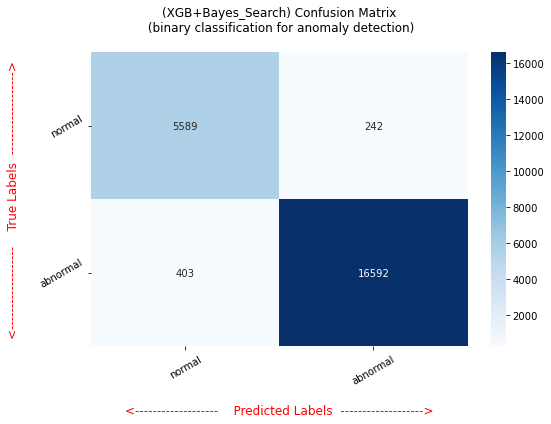

In [43]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(bayes_conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(XGB+Bayes_Search) Confusion Matrix\n (binary classification for anomaly detection)\n")
plt.tight_layout()
plt.show()

In [44]:
scorez = bayes_best_model.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(10)

,feature,score,f_indice,rank
0,P.1203,0.138610,13,1
1,Del_Rate,0.125398,5,2
2,nb_nodes,0.094918,19,3
3,Height,0.078010,10,4
4,Stall_Dur,0.057786,3,5
5,Del_Time,0.051133,2,6
6,Byte_Size,0.050931,7,7
7,Yu,0.043999,17,8
8,Buff_Level,0.042948,8,9
9,Rep_Level,0.036575,4,10


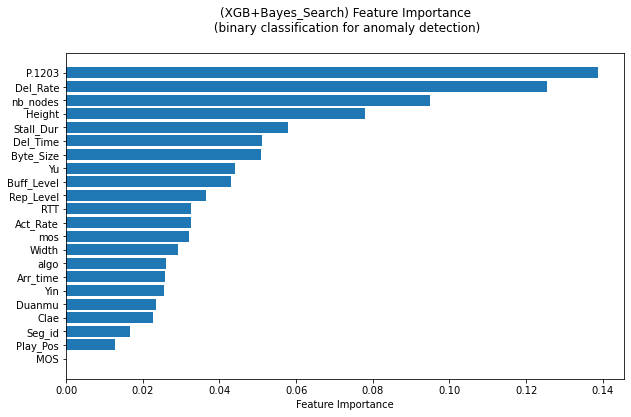

In [45]:
feature_importance = bayes_best_model.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Print and plot feature importance
# print("Feature Importance:")
# for feature, importance in sorted_features:
    # print(f"{feature}: {importance}")

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("(XGB+Bayes_Search) Feature Importance\n (binary classification for anomaly detection)\n")
plt.show()